#### **Importing all the Libraries**

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

#### **Read Reference Images and convert them to grayscale images**

(np.float64(-0.5), np.float64(989.5), np.float64(1319.5), np.float64(-0.5))

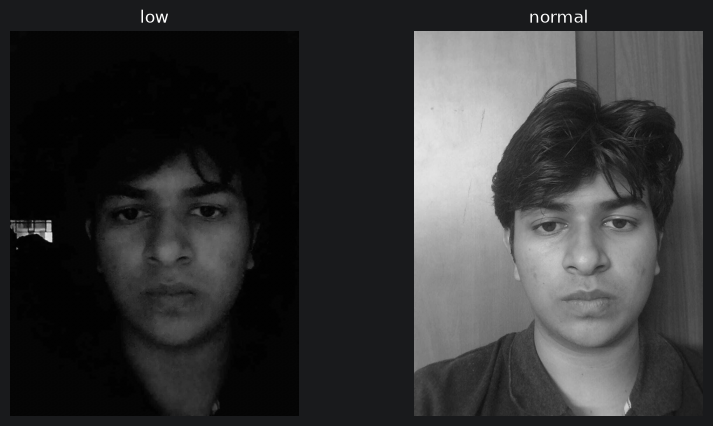

In [7]:
img_low_bgr = cv2.imread("my_image_low.jpg")
img_normal_bgr = cv2.imread("my_image_high.jpg")
gray_normal = cv2.cvtColor(img_normal_bgr, cv2.COLOR_BGR2GRAY)
gray_low = cv2.cvtColor(img_low_bgr, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(gray_low,cmap ='gray');plt.title('low');plt.axis('off')
plt.subplot(142);plt.imshow(gray_normal,cmap = 'gray');plt.title('normal');plt.axis('off')


#### **3. Initialize ORB (Oriented FAST and Rotated BRIEF) Detector and extract keypoints**

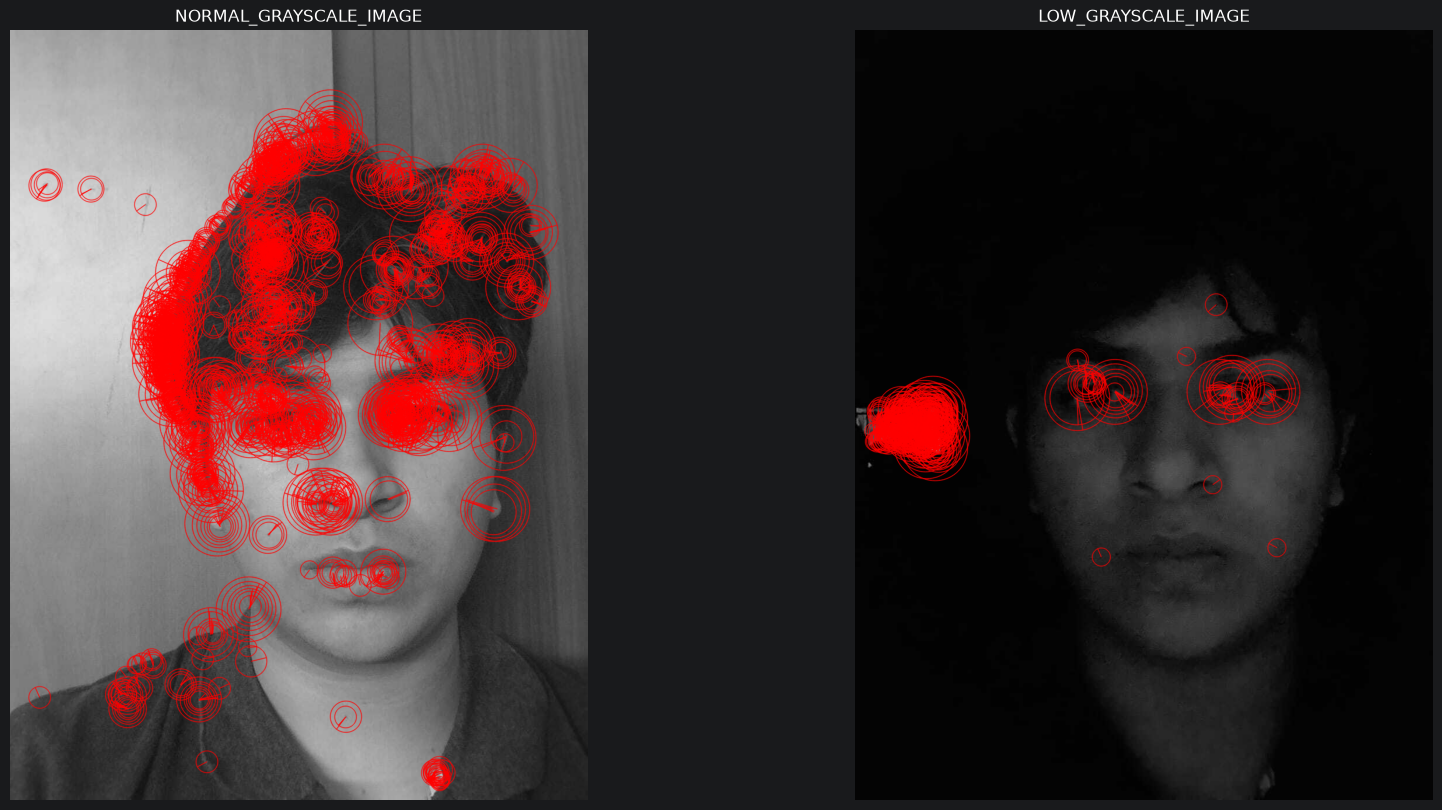

In [8]:
MAX_NUM_FEATURES = 2000
orb = cv2.ORB_create(MAX_NUM_FEATURES)
# Extract keypoints (coordinates) and descriptors (binary arrays describing pixel neighborhoods)
kp_normal, des_normal = orb.detectAndCompute(gray_normal, None)
kp_low, des_low = orb.detectAndCompute(gray_low, None)

#DISPLAY
im1_display = cv2.drawKeypoints(gray_normal, kp_normal, outImage=np.array([]),
                                color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

im2_display = cv2.drawKeypoints(gray_low, kp_low, outImage=np.array([]),
                                color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=[20,10])
plt.subplot(121); plt.axis('off'); plt.imshow(im1_display); plt.title("NORMAL_GRAYSCALE_IMAGE");
plt.subplot(122); plt.axis('off'); plt.imshow(im2_display); plt.title("LOW_GRAYSCALE_IMAGE");

#### **Match Keypoints in the two images**

Text(0.5, 1.0, 'Original Form')

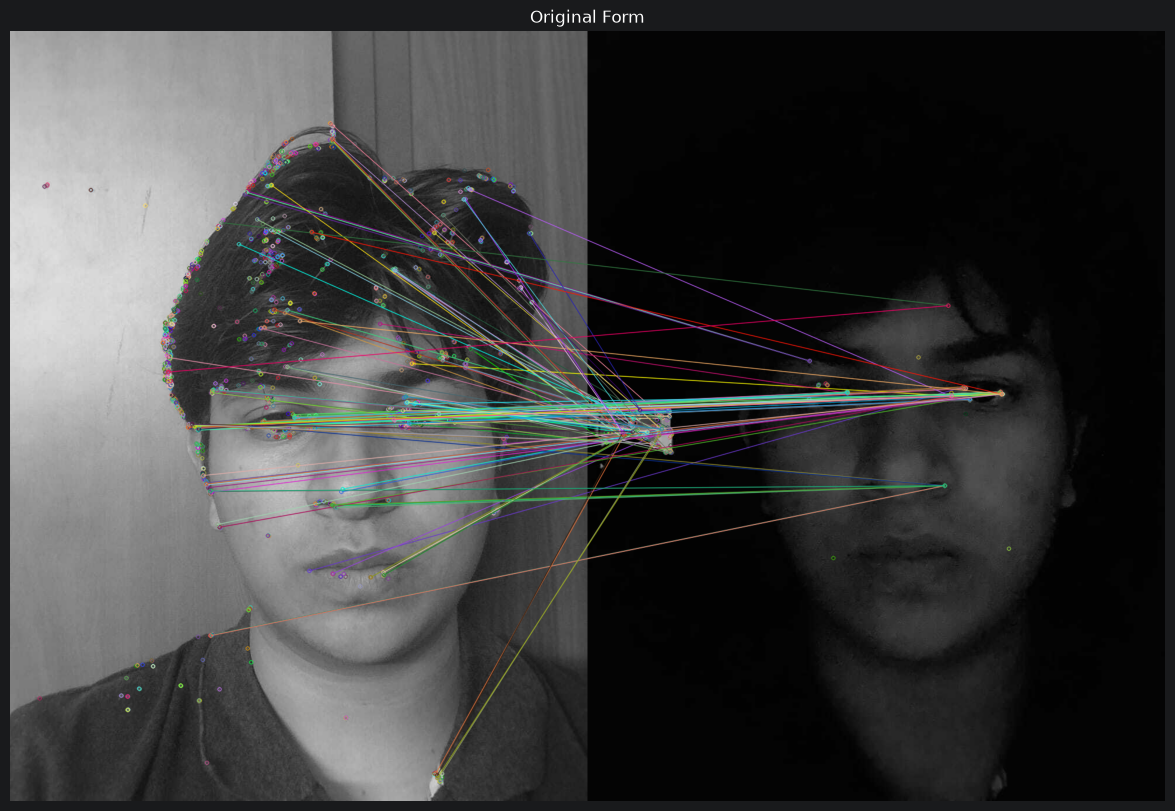

In [9]:
matcher = cv2.DescriptorMatcher.create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(des_normal, des_low,None))
# Sort matches by score
matches.sort(key=lambda x: x.distance, reverse=False)

# Remove not so good matches
numGoodMatches = int(len(matches) * 0.1)
matches = matches[:numGoodMatches]
#Draw top matches
im_matches = cv2.drawMatches(gray_normal, kp_normal, gray_low,kp_low, matches,None)
plt.figure(figsize=[40, 10])
plt.imshow(im_matches);plt.axis("off");plt.title("Original Form")


#### **4. Find Homography using RANSAC**

In [13]:
#Extract Location of good matches
points1 = np.zeros((len(matches), 2),dtype=np.float32)
points2 = np.zeros((len(matches), 2),dtype=np.float32)

#FEATURE TRACKING POINTS IN IMAGE 1 AND IMAGE 2
for i,match in enumerate(matches):
    points1[i,:] = kp_normal[match.queryIdx].pt
    points2[i,:] = kp_low[match.trainIdx].pt

#find homography
h,mask = cv2.findHomography(points1,points2,cv2.RANSAC,5.0)

#### **5.WARP IMAGE**

In [14]:
# Map the low-light image frame directly onto the plane of the normal-light image
height, width, channels = img_normal_bgr.shape
img_low_warped = cv2.warpPerspective(img_low_bgr, h, (width, height))

#### **6.Structural Image Blending via Weighted Addition**

(np.float64(-0.5), np.float64(989.5), np.float64(1319.5), np.float64(-0.5))

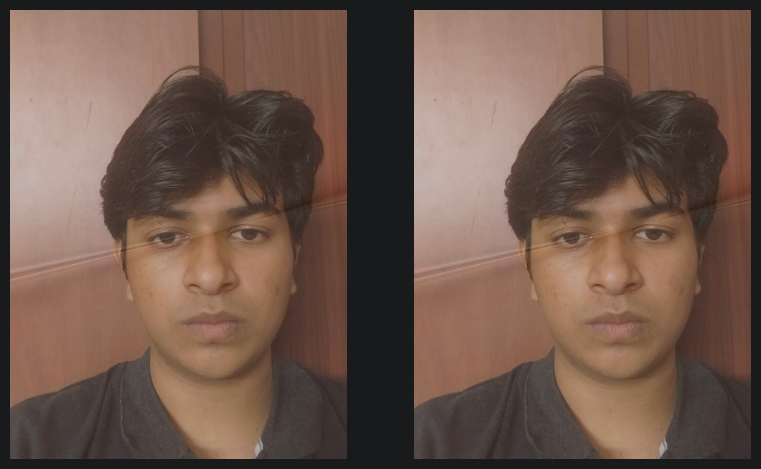

In [16]:
# We generate two distinct weighted combinations to evaluate alignment stability
blend_1 = cv2.addWeighted(img_normal_bgr, 0.7, img_low_warped, 0.7, 0)
blend_2 = cv2.addWeighted(img_normal_bgr, 0.7, img_low_warped, 0.7, 0)

plt.figure(figsize=[20,10])
plt.subplot(141);plt.imshow(cv2.cvtColor(blend_1,cv2.COLOR_BGR2RGB));plt.axis('off')
plt.subplot(142);plt.imshow(cv2.cvtColor(blend_2,cv2.COLOR_BGR2RGB));plt.axis('off')